# Leistungsnachweis

- **Name:** Timo Rolf
- **Matriculation Number:** 22308350
- **Chosen language:** English
- **Corpus Name and Description:** English Wikipedia XML Corpus (Abstracts). This corpus contains the abstracts of all articles from the English Wikipedia, structured as an XML file, making it perfect for natural language processing tasks.
- **Corpus Download URL:** [https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-abstract1.xml.gz](https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-abstract1.xml.gz)

**Note for the professor:** If you choose not to use the automated download cell below, please ensure you manually extract the `.gz` file so that `enwiki-latest-abstract1.xml` is present in the directory!

---

## Solutions to the Task List

*(Solutions will be completed below)*

In [4]:
import os
import urllib.request
import gzip
import shutil

DOWNLOAD = True
# Using a stable, archived URL since latest abstracts are discontinued
corpus_url = 'https://archive.org/download/enwiki-20210820/enwiki-20210820-abstract1.xml.gz'
corpus_gz = 'enwiki-20210820-abstract1.xml.gz'
corpus_xml = 'enwiki-20210820-abstract1.xml'

if DOWNLOAD:
    if not os.path.exists(corpus_xml):
        if not os.path.exists(corpus_gz):
            print(f"Downloading {corpus_gz}...")
            try:
                req = urllib.request.Request(corpus_url, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req) as response, open(corpus_gz, 'wb') as out_file:
                    out_file.write(response.read())
                print(f"Successfully downloaded {corpus_gz}")
            except Exception as e:
                print(f"Failed to download {corpus_gz}: {e}")
        
        if os.path.exists(corpus_gz):
            print(f"Extracting {corpus_gz} to {corpus_xml}...")
            with gzip.open(corpus_gz, 'rb') as f_in:
                with open(corpus_xml, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            print("Extraction complete!")
            os.remove(corpus_gz)
            print(f"Deleted the compressed file {corpus_gz} as it is no longer needed.")
    else:
        print(f"{corpus_xml} already exists in the directory. No download/extraction necessary.")
else:
    print("DOWNLOAD is set to False. Skipping download step.")

enwiki-20210820-abstract1.xml already exists in the directory. No download/extraction necessary.


## Preprocessing XML to Plain Text

The raw XML dataset is quite massive and contains a lot of metadata. We only want to train/evaluate our models and analyses on the actual text content of the abstracts. Therefore, we parse the large `.xml` file iteratively (to save memory) and extract solely the text within `<abstract>` tags into a neat, cleaned `.txt` file.

In [5]:
import os
import xml.etree.ElementTree as ET
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

corpus_xml = 'enwiki-20210820-abstract1.xml'
corpus_txt = 'enwiki-20210820-abstract1.txt'

if os.path.exists(corpus_xml):
    if not os.path.exists(corpus_txt):
        print(f"Extracting abstracts from {corpus_xml} to {corpus_txt}...")
        
        file_size = os.path.getsize(corpus_xml)
        
        with open(corpus_txt, 'w', encoding='utf-8') as f_out:
            # We wrap the file read stream with tqdm so it tracks the bytes read out of the total file size
            # instead of counting iterating nodes without knowing the total length.
            with tqdm.wrapattr(open(corpus_xml, 'rb'), "read", total=file_size, desc="Parsing XML") as f_in:
                context = ET.iterparse(f_in, events=('end',))
                
                # The structure features <abstract> tags inside <doc> tags.
                for event, elem in context:
                    if elem.tag == 'abstract':
                        if elem.text:
                            text = elem.text.strip()
                            # Some abstracts are technically empty or start with formatting
                            if text and not text.startswith('|'):
                                f_out.write(text + '\n')
                    # clear() helps reduce memory consumption while iteratively parsing
                    elem.clear()
        
        print(f"Extraction successful! Clean dataset saved at: {corpus_txt}")
    else:
        print(f"Cleaned dataset '{corpus_txt}' already exists. Skipping preprocessing.")
else:
    print(f"Source file '{corpus_xml}' not found. Did you download and extract it in the cell above?")

Cleaned dataset 'enwiki-20210820-abstract1.txt' already exists. Skipping preprocessing.


In [6]:
import os

corpus_txt = 'enwiki-20210820-abstract1.txt'

if os.path.exists(corpus_txt):
    size_bytes = os.path.getsize(corpus_txt)
    size_mb = size_bytes / (1024 * 1024)
    print(f"File '{corpus_txt}' found.")
    print(f"Size of cleaned dataset: {size_mb:.2f} MB")
else:
    print(f"File '{corpus_txt}' not found. Please run the preprocessing cell above.")

File 'enwiki-20210820-abstract1.txt' found.
Size of cleaned dataset: 49.57 MB


In [7]:
from nltk.corpus import PlaintextCorpusReader

corpus_file_txt = 'enwiki-20210820-abstract1.txt'

# NLTK expects a directory (root) and a regex or file name
corpus_root = '.'
print(f"Loading corpus {corpus_file_txt} via PlaintextCorpusReader...")
enwiki_corpus = PlaintextCorpusReader(corpus_root, corpus_file_txt)

# Print a bit of text to make sure it works!
print("\nSuccessfully loaded! Here are the first 20 words in the cleaned corpus:")
print(enwiki_corpus.words()[:20])

# You can now use enwiki_corpus.words() or enwiki_corpus.sents() for the rest of the exercises!

Loading corpus enwiki-20210820-abstract1.txt via PlaintextCorpusReader...

Successfully loaded! Here are the first 20 words in the cleaned corpus:
['Anarchism', 'is', 'a', 'political', 'philosophy', 'and', 'movement', 'that', 'is', 'sceptical', 'of', 'authority', 'and', 'rejects', 'all', 'involuntary', ',', 'coercive', 'forms', 'of']


c:\Users\timor\Desktop\Hochschule\Semester 4\Sprachverarbeitung\venv\Lib\site-packages\nltk\data.py:388: RuntimeWarning: Security Warning [pathsec.open]: Path C:\Users\timor\Desktop\Hochschule\Semester 4\Sprachverarbeitung\midterm2\enwiki-20210820-abstract1.txt allowed via CWD.
  stream = _secure_open(self._path, "rb")


# Task 4: Lexical Richness

In [8]:
text1 = enwiki_corpus.raw()
len(set(text1)) / len(text1)

c:\Users\timor\Desktop\Hochschule\Semester 4\Sprachverarbeitung\venv\Lib\site-packages\nltk\corpus\reader\api.py:218: RuntimeWarning: Security Warning [CorpusReader]: Path C:\Users\timor\Desktop\Hochschule\Semester 4\Sprachverarbeitung\midterm2\enwiki-20210820-abstract1.txt allowed via CWD.
  with self.open(f) as fp:


7.884850515941128e-05

## Helper Plotting Function

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_frequency_distribution(fdist, title, xlabel, ylabel, limit=20, color='royalblue'):
    """
    Plots a beautiful, clean bar chart of a given NLTK FreqDist or a list of (element, count) tuples.
    Avoids scientific notation on the y-axis, adding comma separation instead.
    """
    # If a FreqDist is passed, get the most common elements.
    # Otherwise, assume it's already a list of tuples.
    if hasattr(fdist, 'most_common'):
        data = fdist.most_common(limit)
    else:
        data = fdist[:limit]
        
    labels, counts = zip(*data)
    
    plt.figure(figsize=(12, 6))
    plt.bar(labels, counts, color=color, edgecolor='black', alpha=0.8)
    
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=12, labelpad=10)
    plt.ylabel(ylabel, fontsize=12, labelpad=10)
    
    # Format the y-axis to display full numbers with commas instead of scientific notation
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Task 5: Character Distribution

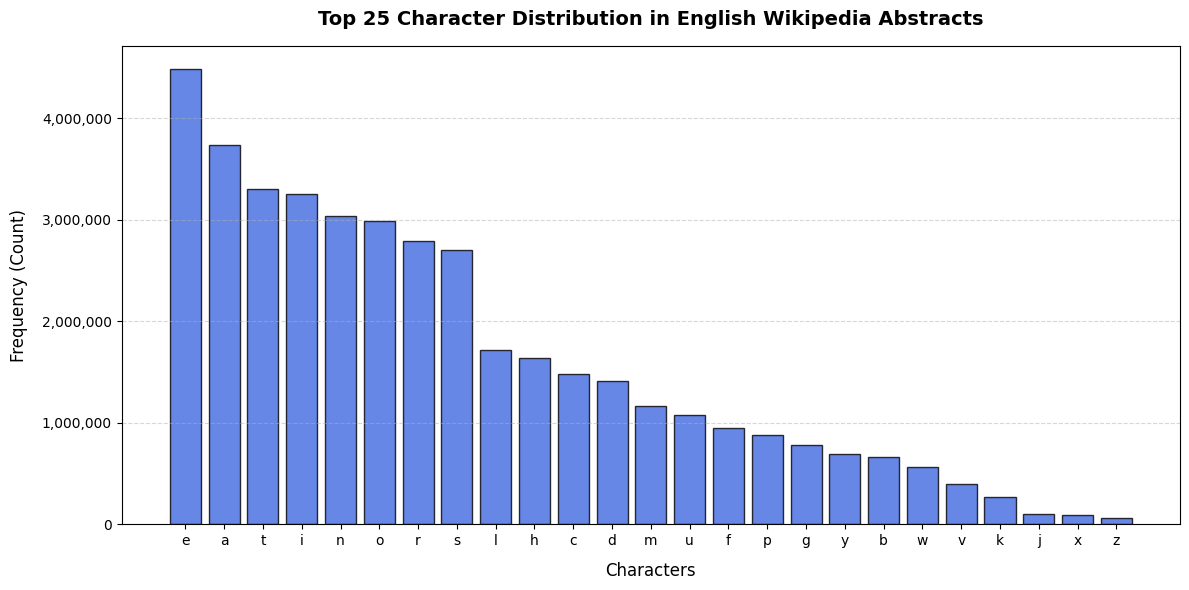

In [10]:
import nltk

# Get frequency distribution of alphabetic characters
fdist = nltk.FreqDist(ch.lower() for ch in text1 if ch.isalpha())

# Plot the distribution using the reusable helper function
plot_frequency_distribution(
    fdist, 
    title="Top 25 Character Distribution in English Wikipedia Abstracts", 
    xlabel="Characters", 
    ylabel="Frequency (Count)", 
    limit=25, 
    color='royalblue'
)

# [Optional] Task 13: Remove Stopwords

*Note: You can use the flag below to remove stopwords if you want to skip ahead to Task 13!*

In [11]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
# Configure this flag to toggle stopwords setup
REMOVE_STOPWORDS = True

english_stopwords = set(stopwords.words('english'))

print(f"Stopwords are {'REMOVED' if REMOVE_STOPWORDS else 'INCLUDED'} for the following analysis.")

# Tokenize and lowercase all alphabetic words from the corpus
if REMOVE_STOPWORDS:
    all_words = [w.lower() for w in enwiki_corpus.words() if w.isalpha() and w.lower() not in english_stopwords]
else:
    all_words = [w.lower() for w in enwiki_corpus.words() if w.isalpha()]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\timor\Desktop\Hochschule\Semester 4\Sprachverarbeitung\venv\Lib\site-packages\nltk\data.py:388: RuntimeWarning: Security Warning [pathsec.open]: Path C:\Users\timor\Desktop\Hochschule\Semester 4\Sprachverarbeitung\midterm2\enwiki-20210820-abstract1.txt allowed via CWD.
  stream = _secure_open(self._path, "rb")


Stopwords are REMOVED for the following analysis.


# Task 6: Word Distribution

Top 20 most common words (without stopwords):
[('may', 48437), ('refer', 41892), ('also', 21973), ('known', 20340), ('united', 19695), ('one', 18564), ('thumb', 17962), ('states', 17382), ('first', 16327), ('used', 16257), ('american', 15629), ('name', 15213), ('new', 12032), ('two', 11202), ('right', 11186), ('born', 10211), ('english', 9532), ('world', 9460), ('county', 9408), ('british', 8502)]


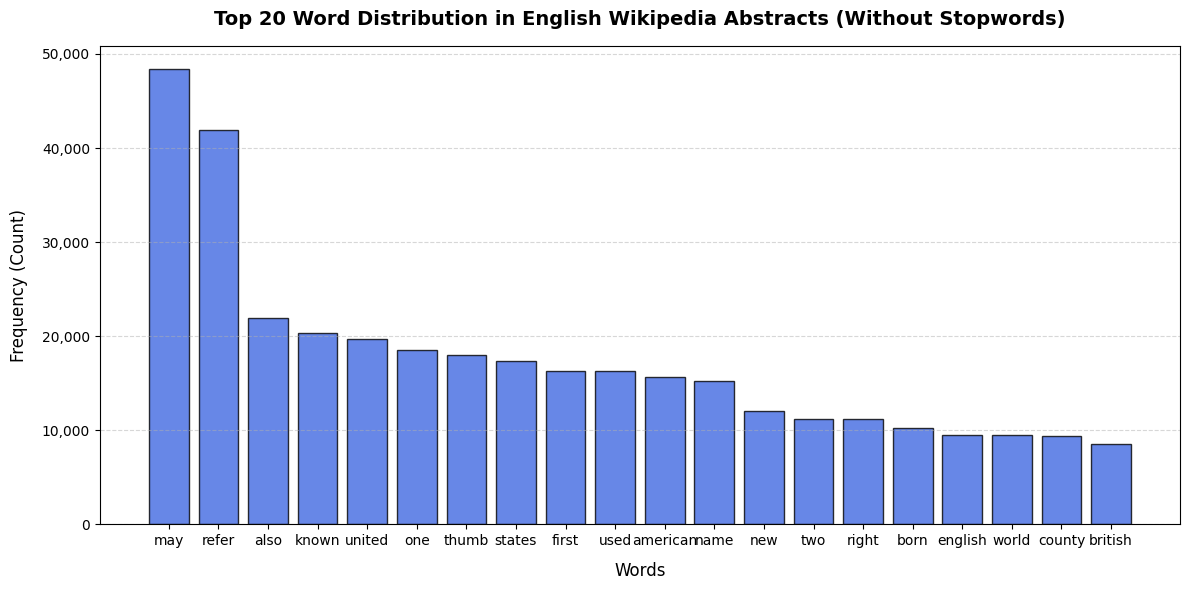

In [12]:
# Calculate frequency distribution
word_fdist = nltk.FreqDist(all_words)

# Print the 20 most common words
most_common_words = word_fdist.most_common(20)
print(f"Top 20 most common words ({'without' if REMOVE_STOPWORDS else 'with'} stopwords):")
print(most_common_words)

# Plot the distribution using our reusable plotting function
plot_frequency_distribution(
    word_fdist, 
    title=f"Top 20 Word Distribution in English Wikipedia Abstracts ({'Without' if REMOVE_STOPWORDS else 'With'} Stopwords)", 
    xlabel="Words", 
    ylabel="Frequency (Count)", 
    limit=20, 
    color='royalblue'
)

# Task 7: Dispersion Plot

<Figure size 1200x600 with 0 Axes>

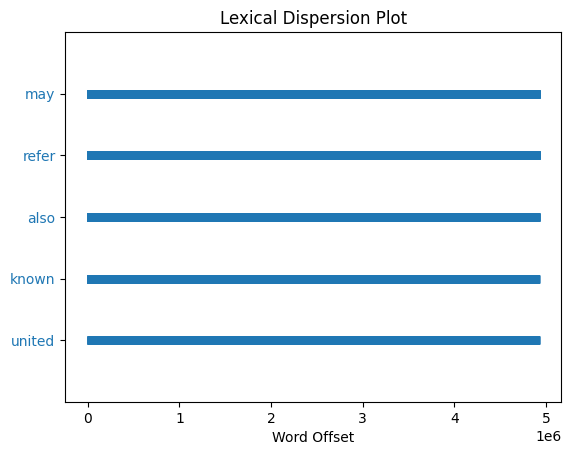

In [13]:
# Create an NLTK Text object using the lowercased alphabetic words list
text_obj = nltk.Text(all_words)

# Plot the dispersion of the 5 most common words
# We customize the figure size before plotting for a clean and readable chart
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

common_words = [w for w, c in word_fdist.most_common(5)]
plot = text_obj.dispersion_plot(common_words)

# Task 8: Longest Word and Maximum Matching Word Segmentation

*Note: The longest word turned out to be a german word which was the filename of a file, so not really a good representative sample. Therefore, we use output the 5 longest word and split each one using the Maximum Matching Word Segmentation Algorithm.

In [14]:
import nltk
nltk.download('words')
from nltk.corpus import words

# Use a set with lowercased words for O(1) lookup
english_dict = set(w.lower() for w in words.words())

# Sort unique words by length in descending order
unique_words_by_length = sorted(set(all_words), key=len, reverse=True)

# Select the top 5 longest words
top_5_longest = unique_words_by_length[:5]

def max_match(text, dictionary):
    """
    Maximum Matching Word Segmentation Algorithm.
    Starting from the beginning of the text, it iterates through decreasing prefix lengths
    seeking the longest substring that appears in the given dictionary.
    Skips characters/sequences that are not part of the dictionary instead of matching them as single characters.
    """
    segmented_words = []
    i = 0
    while i < len(text):
        j = len(text)
        match_found = False
        # Narrow down the search range from the full remaining length to 1
        while j > i:
            substring = text[i:j]
            if substring in dictionary:
                segmented_words.append(substring)
                i = j
                match_found = True
                break
            j -= 1
            
        if not match_found:
            # If no dictionary word can be formed starting at index i, skip this character
            i += 1
            
    return segmented_words

print("Top 5 longest words and their Maximum Matching Word Segmentation:\n")
for word in top_5_longest:
    subwords = max_match(word, english_dict)
    print(f"Original: '{word}' (length: {len(word)})")
    print(f"Segmented: [{', '.join(subwords)}]\n")


[nltk_data] Downloading package words to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


Top 5 longest words and their Maximum Matching Word Segmentation:

Original: 'donaudampfschiffahrtselektrizitätenhauptbetriebswerkbauunterbeamtengesellschaft' (length: 79)
Segmented: [don, a, ud, am, p, f, s, chi, f, fa, h, r, t, sele, k, tri, z, it, ten, hau, p, t, bet, rie, b, s, wer, k, ba, u, un, te, r, beam, teng, es, ell, s, chaft]

Original: 'dagisthaeusbessasmartinvalerianbouzesbelisariusjustingubazes' (length: 60)
Segmented: [dag, ist, ha, eu, s, bess, as, martin, valerian, bo, u, z, es, belis, arius, justin, g, u, baze, s]

Original: 'pneumonoultramicroscopicsilicovolcanoconiosis' (length: 45)
Segmented: [p, ne, um, on, o, ultramicroscopic, silico, volcano, coniosis]

Original: 'darbymediahammontonnorristowndoylestowncherry' (length: 45)
Segmented: [darby, media, ham, monton, nor, rist, own, doyle, stow, n, cherry]

Original: 'townshipdowningtownphoenixvillepottstownking' (length: 44)
Segmented: [township, downing, town, phoenix, ville, pott, stow, n, king]



# Task 9: Short Sentence and Context-Free Grammar

We select a 5-word sentence and create a context-free grammar to show its syntactical structure.

In [15]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Find a short sentence with exactly 5 words (treating only alphabetic tokens as 'words')
print("Finding a 5 word sentence...")
selected_sent_text = ""

skip_line_offset = 150 # Change this value to get a different sentence

with open('enwiki-20210820-abstract1.txt', 'r', encoding='utf-8') as f:
    for _ in range(skip_line_offset):
        next(f, None)
        
    for line in f:
        sentences = sent_tokenize(line)
        for sent in sentences:
            words = word_tokenize(sent)
            alpha_words = [w for w in words if w.isalpha()]
            if len(alpha_words) == 5:
                selected_sent_text = sent
                break
        if selected_sent_text:
            break

if not selected_sent_text:
    selected_sent_text = "It derives from fluid dynamics ."

print(f"Selected short sentence: {selected_sent_text}\n")

grammar_str = """
  S -> NP VP PUNCT
  VP -> V PP
  PP -> P NP
  NP -> 'It' | ADJ N
  V -> 'derives'
  P -> 'from'
  ADJ -> 'fluid'
  N -> 'dynamics'
  PUNCT -> '.'
"""

grammar = nltk.CFG.fromstring(grammar_str)

sentence = word_tokenize(selected_sent_text)

parser = nltk.RecursiveDescentParser(grammar)
for tree in parser.parse(sentence):
    tree.pretty_print()

Finding a 5 word sentence...
Selected short sentence: It derives from fluid dynamics.

             S                               
  ___________|____________________________    
 |                VP                      |  
 |      __________|____                   |   
 |     |               PP                 |  
 |     |      _________|____              |   
 |     |     |              NP            |  
 |     |     |          ____|_____        |   
 NP    V     P        ADJ         N     PUNCT
 |     |     |         |          |       |   
 It derives from     fluid     dynamics   .  



# Task 10: Part-of-Speech Tagging

Here we apply NLTK's recommended Part-of-Speech (POS) tagger to the words in our short sentence.

In [16]:
import nltk
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

# Download required tokenization and POS tagging models
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# We use the selected_sent_text found in the cell above
print(f"Applying POS tagger to: {selected_sent_text}\n")

tokens = word_tokenize(selected_sent_text)
print(f"Tokens: {tokens}\n")

# Use NLTK's recommended pos_tag
tagged_tokens = pos_tag(tokens)
print("Part-of-Speech Tags:")
for token, tag in tagged_tokens:
    print(f"{token:15} ->  {tag}")

Applying POS tagger to: It derives from fluid dynamics.

Tokens: ['It', 'derives', 'from', 'fluid', 'dynamics', '.']

Part-of-Speech Tags:
It              ->  PRP
derives         ->  VBZ
from            ->  IN
fluid           ->  NN
dynamics        ->  NNS
.               ->  .


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


# Task 11: Stemming the Selected Sentence

Here we apply the Porter Stemmer algorithm to reduce each word in our chosen sentence down to its base stem.

In [17]:
from nltk.stem import PorterStemmer

# Initialize the Porter Stemmer
porter = PorterStemmer()

print(f"Original sentence: {selected_sent_text}\n")
print(f"Original tokens:   {tokens}\n")

# Stem each token
stemmed_tokens = [porter.stem(token) for token in tokens]

print(f"Stemmed tokens:    {stemmed_tokens}\n")

# Display the mapping clearly
print("Token -> Stem Mapping:")
for token, stem in zip(tokens, stemmed_tokens):
    print(f"{token:15} ->  {stem}")

Original sentence: It derives from fluid dynamics.

Original tokens:   ['It', 'derives', 'from', 'fluid', 'dynamics', '.']

Stemmed tokens:    ['it', 'deriv', 'from', 'fluid', 'dynam', '.']

Token -> Stem Mapping:
It              ->  it
derives         ->  deriv
from            ->  from
fluid           ->  fluid
dynamics        ->  dynam
.               ->  .


# Task 12: Lemmatization

We will use the `WordNetLemmatizer` for the English language. Since the lemmatizer requires POS tags in WordNet format, we need to map our previously generated Penn Treebank POS tags to the WordNet POS tags.

In [18]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# Download WordNet corpora if not already present
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Helper function to map Penn Treebank tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        # As a fallback, WordNetLemmatizer defaults to Noun
        return wordnet.NOUN

print("Token -> Lemmatized (Lemma) Mapping:")

lemmatized_tokens = []
# We use 'tagged_tokens' from Task 9 & 10
for token, tag in tagged_tokens:
    wn_pos = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(token, pos=wn_pos)
    lemmatized_tokens.append(lemma)
    print(f"{token:15} ({tag:4}) ->  {lemma}")

print(f"\nFinal lemmatized tokens: {lemmatized_tokens}")

Token -> Lemmatized (Lemma) Mapping:


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\timor\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


It              (PRP ) ->  It
derives         (VBZ ) ->  derive
from            (IN  ) ->  from
fluid           (NN  ) ->  fluid
dynamics        (NNS ) ->  dynamic
.               (.   ) ->  .

Final lemmatized tokens: ['It', 'derive', 'from', 'fluid', 'dynamic', '.']


# Task 14: Wordcloud without Stopwords

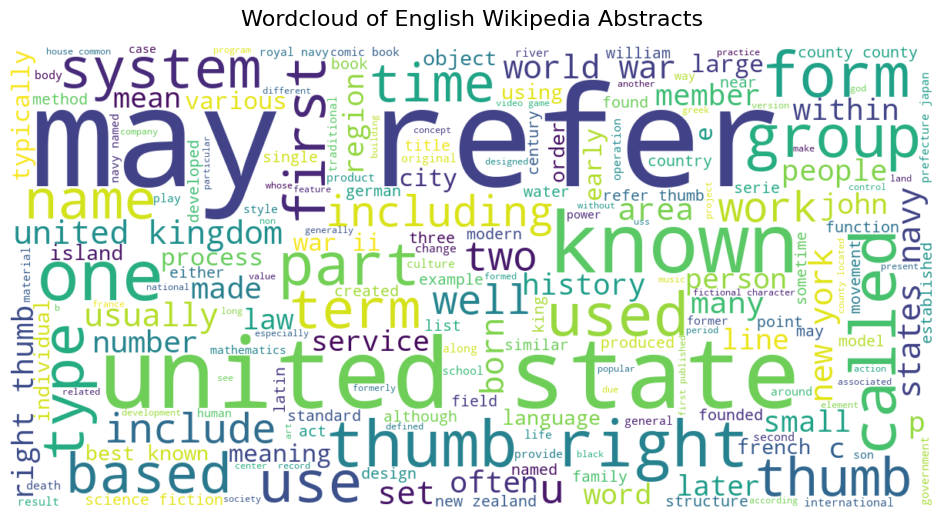

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

if not REMOVE_STOPWORDS:
    print("WARNING: Stopwords are currently not bypassed. Please toggle REMOVE_STOPWORDS = True in the cell above Task 6 and rerun to generate a clean Wordcloud.")

# Re-join all words (which already have stopwords filtered if REMOVE_STOPWORDS is true)
text_for_cloud = " ".join(all_words)

# Generate and plot the wordcloud
wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white', 
    colormap='viridis',
    min_font_size=10
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Wordcloud of English Wikipedia Abstracts", fontsize=16, pad=15)
plt.show()

# Prompt Library

Note: Large Language Models assisted to create this notebook. The following models have been used:
- Gemini 3.1 Pro (Preview) Medium - Github Copilot
- Gemini 3.5 Flash - Google Antigravity Agent

All used prompts have been documented below.

> Take a look at the Task List. Write the first cell of midterm_notebook.ipynb.
> 
> Name: "Timo Rolf"
> Matriculation Number: 22308350
> I want to choose the german wikipedia corpus (find the link).
> 
> Leave the solution blank for now.

> Add a Download cell below. It should be optional, so add a global Variable DOWNLOAD = False to the top. Only if this variable is set to True, download the corpus. Check that it is not already downloaded in this case!

> I received more information. Actually, I should use the english version. Adjust the notebook accordingly

> add a check cell to verify the size of the corpus in MB

> Make sure the corpus_url is correct! Make a browser search to verify.
> 
> Failed to download enwiki-latest-abstract1.xml.gz: HTTP Error 404: Not Found

> Adjust the code cell such that it opens the compressed gzipped file and uses the XMLcorpusReader to print a bit of text and make the future tasks easier

> Combine the unzip code into the download code cell. Add a Note to the first .md cell to instruct the professor if he doesn't want to use the Download cell, that he has to extract the file himself. The size verification cell should look at the unzipped file. After unzipping, automatically delete the zipped file as it is not needed anymore. Get rid of the os.path.exists in the XMLCorpusReader cell as this is already present from the size verification cell above.

> I saw you reverted back to the old corpus_url. I changed it to:
> 
> Using a stable, archived URL since latest abstracts are discontinued<br>
> corpus_url = 'https://archive.org/download/enwiki-20210820/enwiki-20210820-abstract1.xml.gz'<br>
> corpus_file = 'enwiki-20210820-abstract1.xml.gz'
> 
> 
> because as of┬á**February 2025**, the Wikimedia Foundation officially discontinued the generation of the page abstract dumps. I switched to an archived version which is still legal to download and use

> Write a cell for task 4, calculating the lexical richness. For this, use the following code from nltk-corpora.ipynb notebook. Keep the cell minimal, but add a clear heading that this is not preprocesing anymore and actually task 4.
> 
> For a description of the difference between the functions `word()` and `word_tokenize()`: see https://stackoverflow.com/questions/46965585/nltk-words-vs-word-tokenize
> 
> The NLTK comes with several tokenizers, see the nltk.tokenize package at https://www.nltk.org/api/nltk.tokenize.html .
> 
> The number of words and how often they are used is a measure of the lexical richness of the text. 
> 
> ~~~~
> text1 = corp1.raw() # Corp1 was read with PlaintextCorpusReader
> 
> len(set(text1)) / len(text1)
> ~~~~

> Implement the character distribution. Use a clear heading with task 5 and stick to the implementation shown earlier in the tutorial notebook nltk-corpora.ipynb

> My file is unsaved currently and I don#t see the updates yet. I get the following message:
> 
> Failed to save 'midterm_notebook.ipynb': The content of the file is newer. Do you want to overwrite the file with your changes?
> 
> What should I do?

> As you can see from the notebook, I got the folowing warning quite a lot of time:
> 
> "UserWarning: Glyph 22781 (\N{CJK UNIFIED IDEOGRAPH-58FD}) missing from font(s) DejaVu Sans."
> 
> Also the graph is totally unreadable. Only display the 25 most common ones! Is it also possible to label the axes in a more descriptive way?

> Actually write out the numbers on the y axis, so no "1e6"

> since we need something like this again for future tasks, write a python function that we can reuse later on

> Go ahead with task 6. Reuse our new helper function!

> excellent. Implement the dispersion plot of the 5 most often used words next. Stick to the implementation from nltk-corpora.ipynb for now! 

> I want you to work on task 8 from the task list in nltk-corpora.ipynb. For this, create a cell in midterm_notebook.ipynb.
> 
> I want to use the Maximum Matching Word Segmentation algorithm. For this, I want you to use the english dictionary built into nltk (download 'words' and then use from nltk.corpus import words).
> 
> Find the longest word using all_words from task 6.

> add an index to the longest_word (i.e. second longest word) and a note to the task 8 cell: The longest word turned out to be a german word which was the filename of a file, so not really a good representative sample.

> adjust the output to just show the top 5 longest words and their segmentation. Also Maximum Matching Word Segmentation skips characters or sequences of letters that are not part of the dictionary!

> implement the task 9 using the pos_tag function. For this, pretokenize the words now and use nltk's recommended part of speech tagger. Here is an example:
> 
> ```
> from nltk.tag import pos_tag
> from nltk.tokenize import word_tokenize
> pos_tag(word_tokenize("John's big idea isn't all that bad.")) 
> ```


> enwiki_corpus.sents() takes a long time. Is it possible to use a generator/ iterator here instead?

> For task 11, implement and use porters stemmer algorithm

> Implement task 12. Since we are using an english corpus, the WordNetLemmatizer from NLTK should be perfect. Since it expects POS tags, we can reuse the ones that we just calculated

> I want a different 5 word sentence. So add a variable called skip_line_offset

> I want you to put the all_words list into the cell above and then add back in Task 6 heading to its own markdown cell. This way the task 13 doesn't get mixed up with task 6

> Perfect. Finally, implement the wordcloud. Use an if statement with a print Warning if stopwords have not been removed yet

> Implement Task 9 for the given sentence. Here is the CFG to be implemented:
> 
> Terminals T = {'It', 'derives', 'from', 'fluid', 'dynamics', '.'}
> Non-Terminals N = {S, NP, VP, PP, P, N, V, ADJ, PUNCT}
> (where Noun Phrase (NP), Verb Phrase (VP), and Prepositional Phrase (PP))
> Start Symbol S
> Productions P:
> 
> S     -> NP VP PUNCT
> VP    -> V PP
> PP    -> P NP
> NP    -> 'It'
> NP    -> ADJ N
> V     -> 'derives'
> P     -> 'from'
> ADJ   -> 'fluid'
> N     -> 'dynamics'
> PUNCT -> '.'
> 
> Create the grammar using  nltk.CFG.fromstring. Since there is no left-recursion in my grammar, use the nltk.RecursiveDescentParser to parse the sentence and use the pretty_print function of nltk to print the parsed tree to the console